In [1]:
import numpy as np
import rebound
import sys
sys.path.insert(0,'../model')
from matplotlib.collections import PatchCollection
import mega
import matplotlib.pyplot as plt
from multiprocessing import Pool
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
cm = plt.colormaps['hot_r']

In [ ]:
# First, run make.py script to cache the constellation data
#!python make.py

In [2]:
# We run the script in parallel. This part is executed on the worker threads.
worker_sims = None
constellation = None
plot_type = None
Ndate = None
def init_worker(_constellation, _plot_type, _Ndate):
    global worker_sims, constellation, plot_type, Ndate
    constellation = _constellation
    plot_type = _plot_type
    Ndate = _Ndate
    worker_sims = {constellation: rebound.Simulation("mega_"+constellation+".bin")}
def getNum(l): 
    latitude=-90+180*l/(Nlat-1)
    row = np.full(Ndate,np.nan)
    for d in range(Ndate):
        month=(d/Ndate)*12 -79/365*12
        lon = mega.length_of_night(month,latitude)
        if plot_type == "max":
            for hour in list(np.arange(-lon/2.0,0,0.125))+list(-np.arange(-lon/2.0,0,0.125)):
                xy, mag = mega.get_stereographic_data(worker_sims, latitude=latitude, month=month, hour=hour, area=800, elevation_cut=10)
                row[d] = np.nanmax([row[d],np.sum(mag < 5.0)])
        elif plot_type == "midnight":
            if (lon>0.0):
                xy, mag = mega.get_stereographic_data(worker_sims, latitude=latitude, month=month, hour=0, area=800, elevation_cut=10)
                row[d] = np.sum(mag < 5.0)
        elif plot_type == "sunset":
            if (lon>0.0) and (lon<24.0):
                xy, mag = mega.get_stereographic_data(worker_sims, latitude=latitude, month=month, hour=-lon/2., area=800, elevation_cut=10)
                row[d] = np.sum(mag < 5.0)
    if constellation=="SXODC":
        row *= 10 # for speed
    return row

In [3]:
def plot(fig, ax, data, title):
    # Plot data
    cb = ax.imshow(data, extent=(0, 12, -90,90), interpolation="nearest", aspect="auto", origin="lower")    
    
    # Labels
    ax.set_xlabel("Date",labelpad=7)
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    
    # Axes
    months = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.xaxis.set_ticks_position("bottom")
    ax2.tick_params(axis="x", which="major", length=0, labelbottom = False)
    ax2.tick_params(axis="x", which="minor", length=0, labelsize=8)
    ax2.set_xticks(np.arange(0.5,12.5,1), labels=months, minor=True)
    ax.tick_params(axis="x",which="major",labelbottom = False,length=4)
    ax.xaxis.set_ticks(np.arange(0,13,1),minor=True)
    ax.tick_params(axis="x",which="major",length=4)
    
    # Grid
    ax.axhline(0, color="white", linestyle="--", linewidth=0.8)
    astlabels = {"S Equinox":79/365*12, "S Solstice":(79/365+0.25)*12, "F Equinox":(79/365+0.5)*12, "W Solstice":(79/365+0.75)*12}
    for label in astlabels:
        ax.axvline(astlabels[label], color="white", linestyle="--", linewidth=0.8)
        ax.text(x=astlabels[label], y=-85, s=label, rotation=90, verticalalignment="bottom", horizontalalignment="right", color="white", size=8)
    fig.colorbar(cb,label="visible satellites V<5")
    return cb


In [5]:
Ndate, Nlat = 21,21
#constellations = ["Stampede"]
constellations = ["SXODC", "Sunrise", "Stampede"]
data_sunset = globals().get("data_sunset", {})
for constellation in constellations:
    with Pool(processes=80, initializer=init_worker, initargs=(constellation,"sunset",Ndate)) as p:
        data_sunset[constellation] = np.array(p.map(getNum, range(Nlat)))

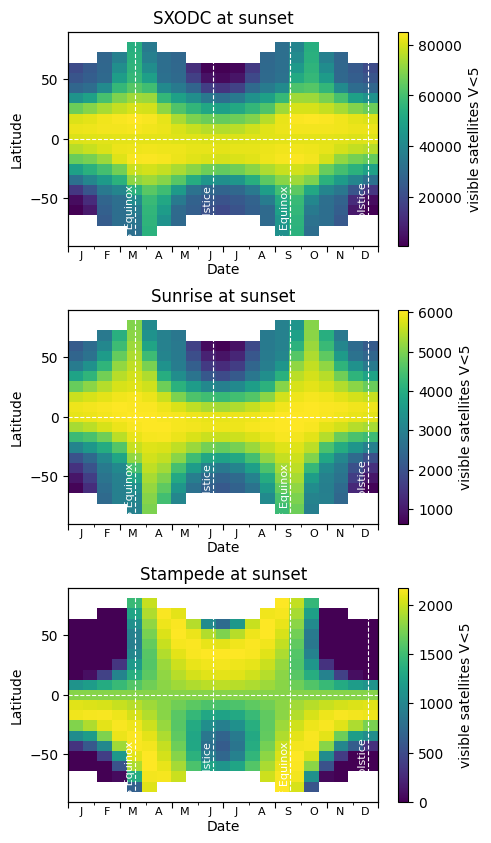

In [7]:
fig, axs = plt.subplots(len(constellations),figsize=(5,10))
plt.subplots_adjust(hspace=0.3)
for i, constellation in enumerate(constellations):
    cb = plot(fig,axs[i],data_sunset[constellation],constellation+" at sunset")    

In [4]:
Ndate, Nlat = 21,21
#constellations = ["Stampede"]
constellations = ["SXODC", "Sunrise", "Stampede"]
data_midnight = globals().get("data_midnight", {})
for constellation in constellations:
    with Pool(processes=80, initializer=init_worker, initargs=(constellation,"midnight",Ndate)) as p:
        data_midnight[constellation] = np.array(p.map(getNum, range(Nlat)))

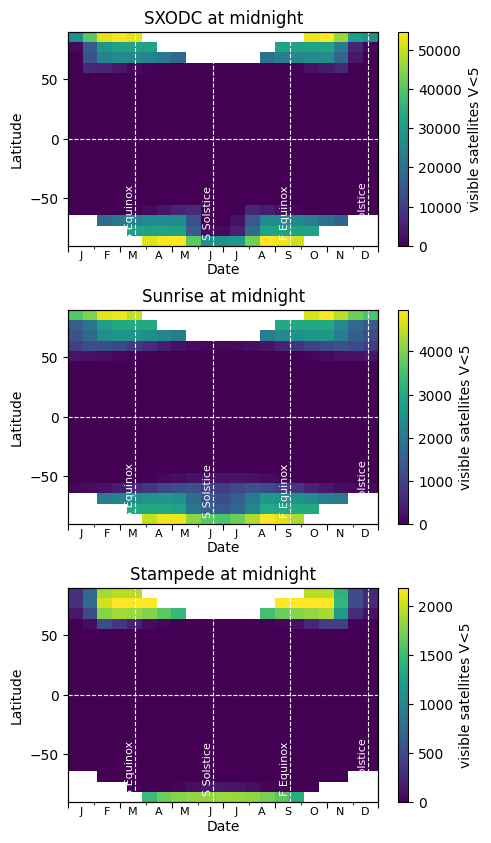

In [6]:
fig, axs = plt.subplots(len(constellations),figsize=(5,10))
plt.subplots_adjust(hspace=0.3)
for i, constellation in enumerate(constellations):
    cb = plot(fig,axs[i],data_midnight[constellation],constellation+" at midnight")    

In [ ]:
Ndate, Nlat = 21,21
#constellations = ["Stampede"]
constellations = ["SXODC", "Sunrise", "Stampede"]
data_max = globals().get("data_max", {})
for constellation in constellations:
    with Pool(processes=80, initializer=init_worker, initargs=(constellation,"max",Ndate)) as p:
        data_max[constellation] = np.array(p.map(getNum, range(Nlat)))

In [ ]:
fig, axs = plt.subplots(len(constellations),figsize=(5,10))
plt.subplots_adjust(hspace=0.3)
for i, constellation in enumerate(constellations):
    cb = plot(fig,axs[i],data_max[constellation],constellation+" max")    